# SMS Spam Detection

The file we are going to use contains a collection of more than 5 thousand SMS phone messages. Using labeled ham and spam examples, we'll train a machine learning model to learn to discriminate between ham/spam automatically. Then, with a trained model, we'll be able to classify arbitrary unlabeled messages as ham or spam.

Here I am going to develop an SMS spam detector using machine learning techniques. However, before feeding the data to the model, we need to preprocess each SMS using Natural Language Processing (NLP) techniques.

# Summary of building the model


Let me give you a brief idea that I am going to follow in this notebook to create the model:

* First try to understand the data and its distribution with basic EDA with the help of Pandas and Matplotlib libraries. Also, check for any outliers by analysing the distribution graphs.

* Now with the help of NLP library "NLTK", first remove the punctuation and special symbols from all the SMS and then lower case them. You can even tokenize each SMS into sentences and words after removing punctuation & special symbols. Here I am just splitting each SMS into words with white spaces. However, tokenization and parsing may be the best idea to split the texts. Please note that converting all the data to lower case helps in the process of preprocessing and in later stages in the NLP application.

* Then remove the Stopswords from all the SMS.

* After processing each SMS, we will create the WordCloud for Spam and Ham messages for the visual representation of widely used words in both Spam and Ham messages.

* Now we can normalize the text by NLTK lemmatization or stemming or distinguishing by part of speech (POC). However, sometimes these methods don't work well especially for text-messages due to the way a lot of people tend to use abbreviations or shorthand in SMS. E.g. "IDK" for "I don't know" or "wut" for "what". So we will not process the text by these methods.

* For now, we will have the messages as lists of tokens and now we need to convert each of these messages into a vector so that SciKit Learn's algorithm models can work with.

    We'll do that in three steps using the bag-of-words (BOW) model:

    * Count how many times does a word occur in each message (Known as term frequency - TF)

    * Weigh the counts, so that frequent tokens get lower weight (inverse document frequency - IDF)

    * Normalize the vectors to unit length, to abstract from the original text length (L2 norm)

* Once the messages represented as vectors, we can finally train our spam/ham classifier. Now we can actually use almost any sort of classification algorithms like Random Forest, Naive Bayes etc.


# Natural Language Processing (NLP)


Here the messages are in the human-readable language which computer can't understand, so we have to use the NLP to make it possible for computers to read human (natural) language SMS and determine which parts are important.

So, Natural language processing (NLP) is a branch of artificial intelligence that helps computers understand, interpret and manipulate human language.

NLP makes it possible for computers to read the text, hear speech, interpret it, measure sentiment and determine which parts are important.

The input and output of an NLP system can be −

* Speech
* Written Text

# Load the Data
Lets import the Python libraries first and then the file through pandas to get a list of all the lines of text messages:

In [19]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score

In [20]:
# Load the SMS spam dataset from a CSV file using pandas
# 'latin-1' encoding is used to avoid errors caused by special characters
# Display the first 5 rows to verify that the data is loaded correctly
messages = pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv',encoding = 'latin-1')
messages.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [21]:
#Remove the unnecessary columns for dataset and rename the column names
messages = messages.drop(labels = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis = 1)
messages.columns = ["label", "message"]
messages['label'] = messages['label'].map({'ham': 0, 'spam': 1})
messages.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Exploratory Data Analysis
Let's check out some of the stats with some plots and the built-in methods in pandas!

In [22]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   int64 
 1   message  5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


There are total 5572 SMS in this dataset with 2 columns label and message.


In [23]:
messages.describe()

,label
count,5572.000000
mean,0.134063
std,0.340751
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


* There is two unique labels.
* There are some repeated messages as unique is less that the count due to some comman messages.
* Let's use groupby to use describe by label, this way we can begin to think about the features that separate ham and spam!

In [24]:
messages.groupby('label').describe().T

label                                0  \
message count                     4825   
        unique                    4516   
        top     Sorry, I'll call later   
        freq                        30   

label                                                           1  
message count                                                 747  
        unique                                                653  
        top     Please call our customer service representativ...  
        freq                                                    4

  * 4825 ham messages out of which 4516 are unique..
  * 747 span messages out of which 653 are unique.
  * "Sorry, I'll call later" is the most popular ham message with repetition of 30 times.
  * "Please call our customer service representativ..." is the most popular spam message with repetition 4 times.
* As we continue our analysis we want to start thinking about the features we are going to be using. This goes along with the general idea of feature engineering. The better the domain knowledge, better the ability to engineer more features from it.

Feature engineering is the process of using domain knowledge to extract features from raw data via data mining techniques. These features can be used to improve the performance of machine learning algorithms. Feature engineering can be considered as applied machine learning itself.

Let's make a new feature to detect how long the text messages are:

In [25]:
messages['length'] = messages['message'].apply(len)
messages.head()

,label,message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [26]:
# Count the frequency of top 5 messages.
messages['message'].value_counts().rename_axis(['message']).reset_index(name='counts').head()

,message,counts
0,"Sorry, I'll call later",30
1,I cant pick the phone right now. Pls send a me...,12
2,Ok...,10
3,"Wen ur lovable bcums angry wid u, dnt take it ...",4
4,Okie,4


It seems people are really busy. "Sorry, i'll call later" tops the message list with 30 counts with "I cant pick the phone right now. Pls send a message" comes second with 12 counts.

Theres a quite lot of Ok...Okie. in there too.

# Data Visualization

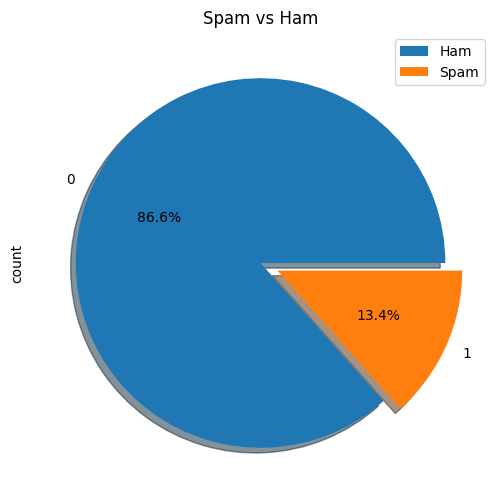

In [27]:
# Plot the distribution of spam vs ham messages as a pie chart to visualize class balance
# The chart shows the percentage of each class with Ham and Spam labels
messages["label"].value_counts().plot(kind = 'pie',explode=[0, 0.1],figsize=(6, 6),autopct='%1.1f%%',shadow=True)
plt.title("Spam vs Ham")
plt.legend(["Ham", "Spam"])
plt.show()

A lot of messages are actually not spam. About 86% of our dataset consists of normal messages.

Text(0, 0.5, 'Frequency')

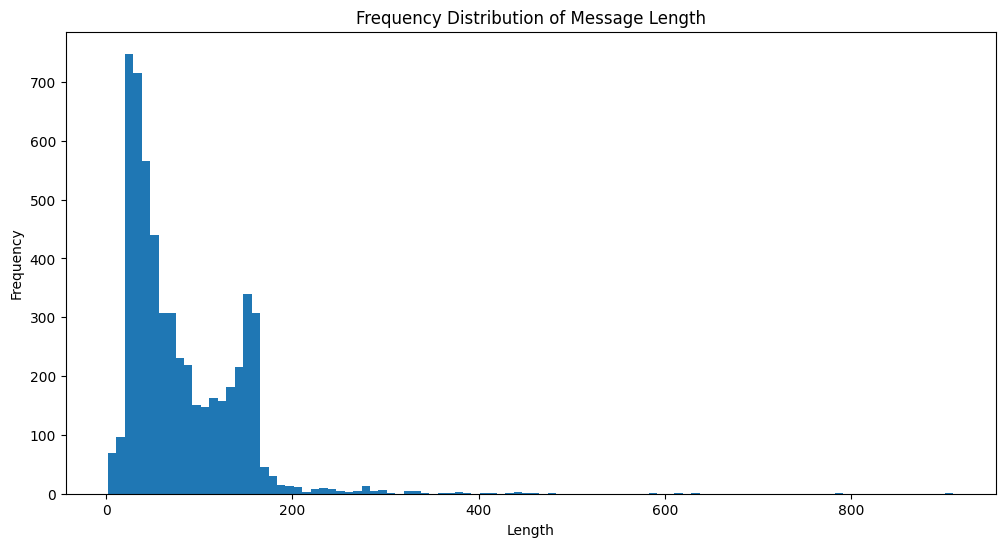

In [28]:
# Plot histogram of message lengths to visualize their frequency distribution
# Helps understand how SMS lengths are spread across the dataset
plt.figure(figsize=(12,6))
messages['length'].plot(bins=100, kind='hist') # with 100 length bins (100 length intervals) 
plt.title("Frequency Distribution of Message Length")
plt.xlabel("Length")
plt.ylabel("Frequency")

Most of the message lenght is less than 200. Note that x-axis goes all the way to 1000ish, this must mean that there is some really long message

In [29]:
messages['length'].describe()

count    5572.000000
mean       80.118808
std        59.690841
min         2.000000
25%        36.000000
50%        61.000000
75%       121.000000
max       910.000000
Name: length, dtype: float64

910 characters, let's use masking to find this message:

In [30]:

# Filter the dataset to find the message(s) with length equal to 910 characters
# Select the 'message' column and extract the first matching value using iloc[0]
messages[messages['length'] == 910]['message'].iloc[0]

"For me the love should start with attraction.i should feel that I need her every time around me.she should be the first thing which comes in my thoughts.I would start the day and end it with her.she should be there every time I dream.love will be then when my every breath has her name.my life should happen around her.my life will be named to her.I would cry for her.will give all my happiness and take all her sorrows.I will be ready to fight with anyone for her.I will be in love when I will be doing the craziest things for her.love will be when I don't have to proove anyone that my girl is the most beautiful lady on the whole planet.I will always be singing praises for her.love will be when I start up making chicken curry and end up makiing sambar.life will be the most beautiful then.will get every morning and thank god for the day because she is with me.I would like to say a lot..will tell later.."

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

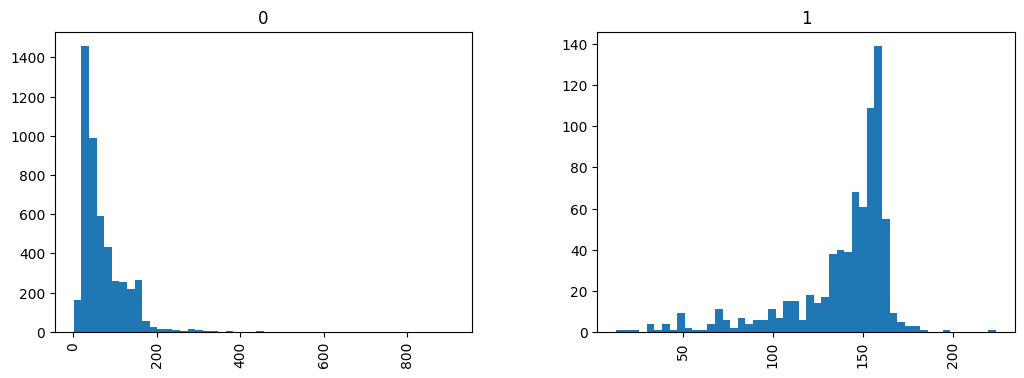

In [31]:
messages.hist(column='length', by='label', bins=50,figsize=(12,4))

Looks like spam messages are usually longer. Maybe message length can become a feature to predict whether the message is spam/ ham ?

#  Text Pre-processing
The data is in text format, while machine learning algorithms require numerical input. Therefore, we will convert the text into numerical feature vectors using the Bag of Words approach.

We will create a function that splits each message into words and removes common words (stopwords) using the NLTK library, then apply it to all messages using Pandas apply().

The first step is to remove punctuation using Python’s built-in string library.

In [32]:
 def text_preprocess(mess):
    """
    Takes in a string of text, then performs the following:
    1. Remove all punctuation
    2. Remove all stopwords
    3. Returns a list of the cleaned text
    """
    # Check characters to see if they are in punctuation
    nopunc = [char for char in mess if char not in string.punctuation]

    # Join the characters again to form the string.
    nopunc = ''.join(nopunc)
    nopunc = nopunc.lower()
    
    # Now just remove any stopwords and non alphabets
    nostop=[word for word in nopunc.split() if word.lower() not in stopwords.words('english') and word.isalpha()]
    
    return nostop

 "tokenize" these spam or ham messages. Tokenization is just the term used to describe the process of converting the normal text strings in to a list of tokens (words that we actually want).

# Data transformation 

In [33]:
messages.head()

,label,message,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [34]:
# Lets remove punctuations/ stopwords from all SMS 
messages["message"] = messages["message"].apply(text_preprocess)

In [35]:
# Conver the SMS into string from lis
messages["message"] = messages["message"].apply(lambda x: ' '.join(x))

In [36]:
messages.head()

,label,message,length
0,0,go jurong point crazy available bugis n great ...,111
1,0,ok lar joking wif u oni,29
2,1,free entry wkly comp win fa cup final tkts may...,155
3,0,u dun say early hor u c already say,49
4,0,nah dont think goes usf lives around though,61


In [37]:
messages["message"][7]

'per request melle melle oru minnaminunginte nurungu vettam set callertune callers press copy friends callertune'

# Continuing Normalization
There are a lot of ways to continue normalizing the text. Such as Stemming or distinguishing by part of speech.

NLTK has lots of built-in tools. However sometimes they don't work well for text-messages due to the way a lot of people tend to use abbreviations or shorthand, For example:

'Nah dawg, IDK! Wut time u headin to da club?'

versus

'No dog, I don't know! What time are you heading to the club?'

Some text normalization methods will have trouble with this type of shorthand and so we are not going to use them here. For now we will just focus on using what we have to convert our list of words to an actual vector that SciKit-Learn can use.

**Vectorization**
Currently, we have the messages as lists of tokens (also known as lemmas) and now we need to convert each of these messages into a vector the SciKit Learn's algorithm models can work with.

Now we'll convert each message, represented as a list of tokens (lemmas) above, into a vector that machine learning models can understand.

We'll do that in three steps using the bag-of-words model:

* Count how many times does a word occur in each message (Known as term frequency or TF)

* Weigh the counts, so that frequent tokens get lower weight (inverse document frequency or IDF)

* Normalize the vectors to unit length, to abstract from the original text length (L2 norm)

Let's begin the first step:

 Each vector will have as many dimensions as there are unique words in the SMS corpus. We will first use SciKit Learn's CountVectorizer. This model will convert a collection of text documents to a matrix of token counts.

 Countvectorizer counts the number of times a token shows up in the messages and uses this value as its weight.

 We can imagine this as a 2-Dimensional matrix. Where the 1-dimension is the entire vocabulary (1 row per word) and the other dimension are the actual documents, in this case a column per text message.

Since there are so many messages, we can expect a lot of zero counts for the presence of that word in that document. Because of this, SciKit Learn will output a Sparse Matrix.

# spilt data

In [38]:
x = messages ['message']
y = messages ['label']
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

# TF-IDF

In [39]:
# using TfidfVectorizer
tfidf = TfidfVectorizer(ngram_range=(1,2)) 
x_train_tfidf = tfidf.fit_transform(x_train) 
x_test_tfidf = tfidf.transform(x_test) 

# naive_bayes

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report
tfidf = TfidfVectorizer()

X_train = tfidf.fit_transform(x_train)
X_test = tfidf.transform(x_test)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.9632286995515695
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.73      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



#  Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Logistic Regression
log_model = LogisticRegression(max_iter=200, class_weight='balanced')
log_model.fit(x_train_tfidf, y_train)

y_pred_log = log_model.predict(x_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9748878923766816
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.91      0.91       150

    accuracy                           0.97      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.97      0.97      0.97      1115



# SVM

In [51]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Create model
svm_model = SVC(kernel='linear', C=1.0, class_weight='balanced')
# kernel: defines decision boundary shape (linear or curved)
# C: controls how strict the model is
# Train model
svm_model.fit(x_train_tfidf, y_train)

# Predict
y_pred_svm = svm_model.predict(x_test_tfidf)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9811659192825112
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.94      0.91      0.93       150

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



# random forest

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score ,classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_tfidf, y_train)

y_pred_rf = rf_model.predict(x_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.967713004484305
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.76      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



# KNN

In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# KNN with TF-IDF
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train
knn_model.fit(x_train_tfidf, y_train)

# Predict
predict_knn_tfidf = knn_model.predict(x_test_tfidf)

# Evaluate
print("Accuracy:", accuracy_score(y_test, predict_knn_tfidf))
print(classification_report(y_test, predict_knn_tfidf))

Accuracy: 0.9076233183856502
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       965
           1       1.00      0.31      0.48       150

    accuracy                           0.91      1115
   macro avg       0.95      0.66      0.71      1115
weighted avg       0.92      0.91      0.89      1115



# # Model Comparison: Accuracy of Different ML Algorithms on TF-IDF Features

In [69]:
from sklearn.metrics import classification_report
import pandas as pd

results = []

predictions = {
    "Logistic Regression": y_pred_log,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "Naive Bayes": y_pred_nb,
    "KNN": predict_knn_tfidf
}

for name, y_pred in predictions.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    })

df = pd.DataFrame(results)
df = df.sort_values(by="Accuracy", ascending=False)

df

,Model,Accuracy,Precision,Recall,F1-Score
1,SVM,0.981166,0.980979,0.981166,0.981031
0,Logistic Regression,0.974888,0.974888,0.974888,0.974888
2,Random Forest,0.967713,0.968874,0.967713,0.965807
3,Naive Bayes,0.963229,0.964727,0.963229,0.960701
4,KNN,0.907623,0.916532,0.907623,0.885814


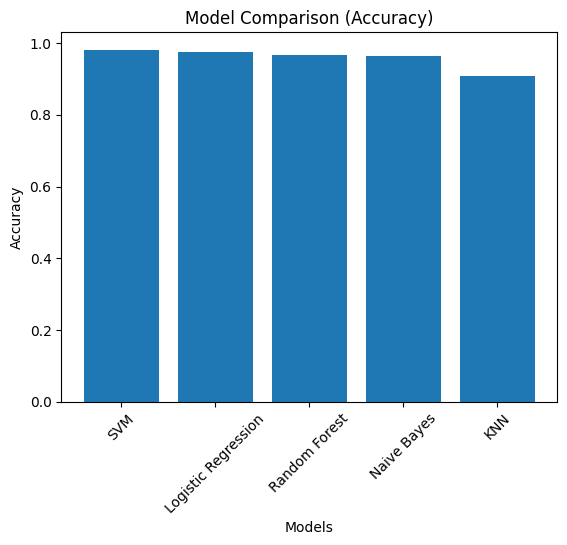

In [70]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(df["Model"], df["Accuracy"])

plt.title("Model Comparison (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)

plt.show()

#  Confusion Matrix Analysis

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [74]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.show()

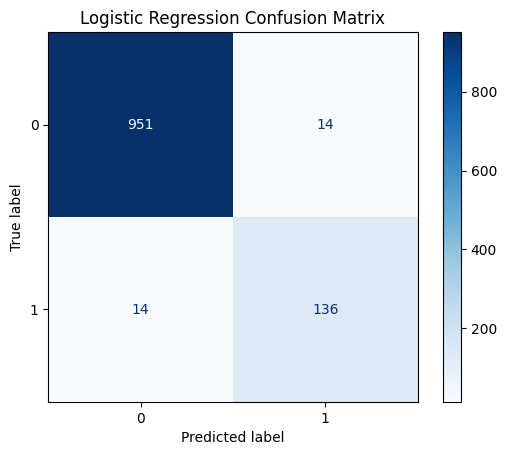

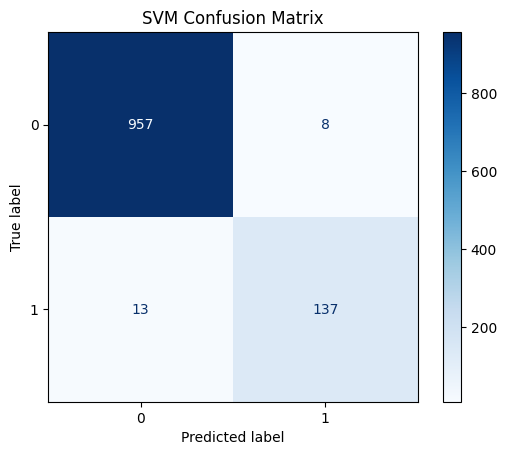

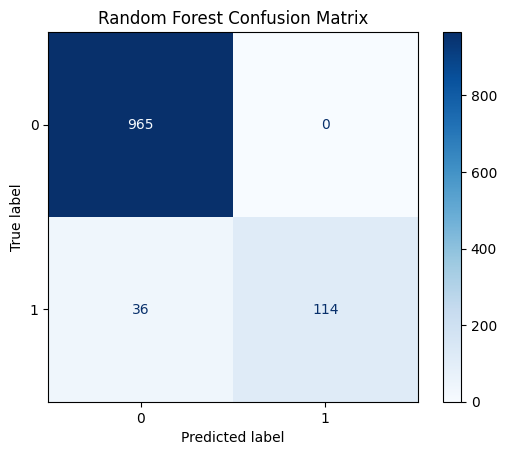

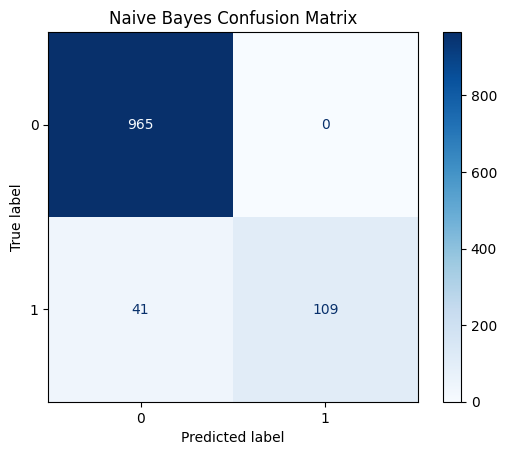

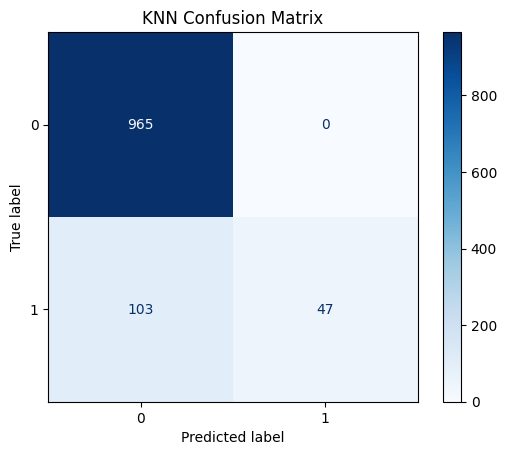

In [76]:
plot_cm(y_test, y_pred_log, "Logistic Regression Confusion Matrix")
plot_cm(y_test, y_pred_svm, "SVM Confusion Matrix")
plot_cm(y_test, y_pred_rf, "Random Forest Confusion Matrix")
plot_cm(y_test, y_pred_nb, "Naive Bayes Confusion Matrix")
plot_cm(y_test,predict_knn_tfidf, "KNN Confusion Matrix")

# GUI

In [71]:
import pickle
from sklearn.svm import SVC

# ==============================
# Rebuild and train SVM model
# ==============================
model_svm = SVC(kernel='linear')
model_svm.fit(x_train_tfidf, y_train)

# ==============================
# Save all trained models
# ==============================
pickle.dump(nb_model, open("nb.pkl", "wb"))
pickle.dump(log_model, open("log.pkl", "wb"))
pickle.dump(model_svm, open("svm.pkl", "wb"))
pickle.dump(model, open("rf.pkl", "wb"))
pickle.dump(knn_model, open("knn.pkl", "wb"))

# Save TF-IDF vectorizer
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))